# Parking

Step 11.2. The handbrake turn of `handbrake.ipynb` between two boxes, the straight ended by the boxes
instead of a time: box A in front of where the car stops, box B along its right side. The stops are
measured with the lidar: the last scans of each run, the car stopped, laid by ICP on the first ones,
the car on the start mark.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

plt.rcParams['figure.dpi'] = 72
B = '../data/bags'
LIDAR_X = 0.09225                                  # lidar ahead of the rear axle (URDF)
FRONT, REAR, HALF_WIDTH = 0.2165, -0.0435, 0.10    # car outline from the rear axle
R_WHEEL = 0.0299
START = (3.010, 0.350, -0.801)                     # the car at the start in Gazebo (sim.launch.py)


def load(run):
    read = lambda name: pd.read_parquet(f'{B}/{run}_parquet/{name}.parquet')
    s, j = read('handbrake_state'), read('joint_states')
    return dict(state=s, scan=read('scan'), t_go=s.loc[s['phase'] == 2, 't'].iloc[0],
                t_turn=s.loc[s['phase'] == 3, 't'].iloc[0], t_brake=s.loc[s['phase'] == 4, 't'].iloc[0],
                t_wheels=j['t'].to_numpy(), wheels=(j['wl'] + j['wr']).to_numpy() / 2 * R_WHEEL)


def scan_xy(m):
    # one scan, points from the rear axle, and the lidar angle of each
    r = np.array(m['ranges'], dtype=float)
    a = m['angle_min'] + np.arange(len(r)) * m['angle_increment']
    ok = np.isfinite(r) & (r < 4.0)
    return np.c_[r[ok] * np.cos(a[ok]) + LIDAR_X, r[ok] * np.sin(a[ok])], a[ok]


def icp(src, dst, x, y, yaw, iters=60):
    # the rigid motion (x, y, yaw) laying the points src on dst, point to point; rms and share of pairs kept
    tree = cKDTree(dst)
    for k in range(iters):
        c, s = np.cos(yaw), np.sin(yaw)
        moved = src @ np.array([[c, s], [-s, c]]) + [x, y]
        d, i = tree.query(moved)
        keep = d < (0.3 if k < 20 else 0.08)
        p, q = moved[keep], dst[i[keep]]
        pm, qm = p.mean(axis=0), q.mean(axis=0)
        U, _, Vt = np.linalg.svd((p - pm).T @ (q - qm))
        R = (U @ Vt).T
        if np.linalg.det(R) < 0:
            Vt[1] *= -1
            R = (U @ Vt).T
        yaw += np.arctan2(R[1, 0], R[0, 0])
        x, y = R @ np.array([x, y]) + qm - pm @ R.T
    return x, y, yaw, np.sqrt(np.mean(d[keep] ** 2)), keep.mean()


def stop_pose(run):
    # the car stopped, in the frame of the car at the start: best of a few starting guesses
    sc = load(run)['scan']
    start = np.vstack([scan_xy(m)[0] for _, m in sc.iloc[:8].iterrows()])
    end = np.vstack([scan_xy(m)[0] for _, m in sc.iloc[-8:].iterrows()])
    best = None
    for x0 in [1.0, 1.3, 1.6, 1.9]:
        for y0 in [0.9, 1.2, 1.5]:
            for yaw0 in np.radians([170, 180, 190]):
                res = icp(end, start, x0, y0, yaw0)
                if best is None or res[4] > best[4] + 0.02 or (abs(res[4] - best[4]) <= 0.02 and res[3] < best[3]):
                    best = res
    return best


def far_at_rest(run):
    # as the node at rest: the side of box A is the nearest line of points left of the path ahead, the
    # far corner the last point of its unbroken row
    p = np.vstack([scan_xy(m)[0] for _, m in load(run)['scan'].iloc[:8].iterrows()])
    ahead_left = (p[:, 0] > 0.2) & (p[:, 0] < 2.0) & (p[:, 1] > 0.3) & (p[:, 1] < 1.6)
    side_y = np.percentile(p[ahead_left, 1], 10)
    xs = np.sort(p[(np.abs(p[:, 1] - side_y) < 0.04) & (p[:, 0] > 0.2), 0])
    return side_y, np.split(xs, np.where(np.diff(xs) > 0.05)[0] + 1)[0][-1]


def gaps(run):
    # the car stopped: its nose to the nearest point ahead within its width, its right side to the
    # nearest point beside it
    end = np.vstack([scan_xy(m)[0] for _, m in load(run)['scan'].iloc[-10:].iterrows()])
    front = end[(np.abs(end[:, 1]) < HALF_WIDTH) & (end[:, 0] > FRONT)]
    right = end[(end[:, 0] > REAR) & (end[:, 0] < FRONT) & (end[:, 1] < -HALF_WIDTH)]
    return np.percentile(front[:, 0], 5) - FRONT, -np.percentile(right[:, 1], 95) - HALF_WIDTH

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## The straight

`hbp_1`-`3` (`handbrake.ipynb`): the straight of the node ends after a time, 1 s ramp and 0.5 s at full
throttle. Box A beside the path is a ruler: the far corner of its side, followed scan by scan, the time
of each point from where the lidar turn was (rplidar_ros stamps the start of the turn, which begins
behind and goes clockwise).

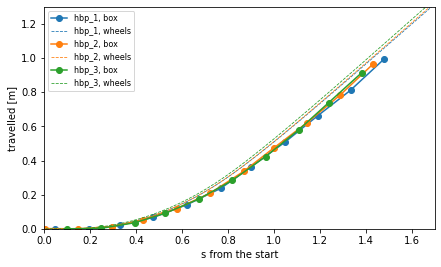

,turn [s],"travelled at the turn, box [m]",wheels [m],stop x [m],stop y [m],stop x - turn [m],ICP rms [cm]
run,,,,,,,
hbp_1,1.520,1.043,1.106,1.266,1.286,0.223,2.280
hbp_2,1.500,1.047,1.090,1.395,1.328,0.348,2.317
hbp_3,1.519,1.079,1.132,1.333,1.328,0.254,2.241


In [2]:
def corner_track(run, side_y):
    # far corner of the side of box A ahead of the rear axle, scan by scan, as the node: the points turned
    # by the gyro heading (the launch veers), the unbroken row of points of the side (a wall further on
    # can cross the same line), the side followed as the car drifts sideways
    d = load(run)
    s = d['state']
    scan_time = np.median(np.diff(d['scan']['stamp']))
    out = []
    for _, m in d['scan'].iterrows():
        p, a = scan_xy(m)
        h = np.interp(m['stamp'], s['t'], s['heading'])
        p = p @ np.array([[np.cos(h), np.sin(h)], [-np.sin(h), np.cos(h)]])
        side = np.abs(p[:, 1] - side_y) < 0.04
        if side.sum() < 5:
            continue
        order = np.argsort(p[side, 0])
        xs, ys, angles = p[side, 0][order], p[side, 1][order], a[side][order]
        rows = np.split(np.arange(len(xs)), np.where(np.diff(xs) > 0.05)[0] + 1)
        row = max(rows, key=len)
        side_y = np.median(ys[row])
        out.append((m['stamp'] + scan_time * (np.pi - angles[row[-1]]) / (2 * np.pi), xs[row[-1]]))
    return np.array(out)


rows = []
fig, ax = plt.subplots(figsize=(7, 4))
for i, (run, side_y) in enumerate([('hbp_1', 0.96), ('hbp_2', 0.95), ('hbp_3', 0.95)]):
    d = load(run)
    tr = corner_track(run, side_y)
    far0 = np.median(tr[tr[:, 0] < d['t_go'], 1])
    straight = (tr[:, 0] > d['t_go']) & (tr[:, 0] < d['t_turn'])
    odo = np.concatenate([[0], np.cumsum(np.diff(d['t_wheels']) * d['wheels'][1:])])
    odo -= np.interp(d['t_go'], d['t_wheels'], odo)
    ax.plot(tr[straight, 0] - d['t_go'], far0 - tr[straight, 1], f'C{i}o-', label=f'{run}, box')
    ax.plot(d['t_wheels'] - d['t_go'], odo, f'C{i}--', lw=0.8, label=f'{run}, wheels')
    # from the last scan before the turn, on with the wheels (the car turning, the side no longer a line)
    t_last, far_last = tr[straight][-1]
    at_turn = far0 - far_last + np.interp(d['t_turn'], d['t_wheels'], d['wheels']) * (d['t_turn'] - t_last)
    x, y, yaw, rms, share = stop_pose(run)
    rows.append({'run': run, 'turn [s]': d['t_turn'] - d['t_go'], 'travelled at the turn, box [m]': at_turn,
                 'wheels [m]': np.interp(d['t_turn'], d['t_wheels'], odo), 'stop x [m]': x, 'stop y [m]': y,
                 'stop x - turn [m]': x - at_turn, 'ICP rms [cm]': 100 * rms})
ax.set(xlim=(0, 1.7), ylim=(0, 1.3), xlabel='s from the start', ylabel='travelled [m]')
ax.legend(fontsize=8)
plt.show()
STRAIGHT = pd.DataFrame(rows).set_index('run')
STRAIGHT.round(3)

### Result

The three straights ended 1.04-1.08 m from the start; the wheels say 1.09-1.13 m, 4-6% more, most of
it in the launch. The stops spread 13 cm along the path (1.27-1.40 m), and that is the turn: 0.22-0.35 m
from the turn to the stop.

## Turning from the box

`handbrake_node` with `box:=true`. At rest the side of box A is the nearest line of points left of
the path, the far corner the last point of its unbroken row. In the straight the points are turned by
the gyro heading (the launch veers 0-5 deg: seen from the car the side tilts out of the 4 cm band), the
corner taken near where it should be by now, with the time of its point; between scans it moves back
with the wheel speed. The turn starts when the corner is `turn_at` (0.26 m) ahead of the rear axle, not
before 1.6 s from the start (below); if the corner is already 5 cm past it then, the box is too close
and the car stops.

Gazebo, box A with its near face 1.35 m (`sim_box5`) and 1.55 m (`sim_box6`) ahead of the start, the
simulated rear x1.5: the corner of the node against the true one, and the stops.

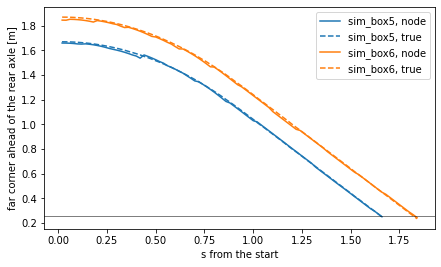

,far face [m],turn [s],corner at the turn [m],stop x [m],stop y [m],stop [deg],stop x - far face [m]
run,,,,,,,
sim_box5,1.67,1.66,0.251,1.685,1.486,183.403,0.015
sim_box6,1.87,1.84,0.244,1.907,1.503,182.478,0.037


In [3]:
def sim_stop(run):
    g = pd.read_parquet(f'{B}/{run}_parquet/ground_truth.parquet')
    x0, y0, yaw0 = START
    dx, dy = g['x'] - x0, g['y'] - y0
    return g['t'], dx * np.cos(yaw0) + dy * np.sin(yaw0), -dx * np.sin(yaw0) + dy * np.cos(yaw0), g['yaw'] - yaw0


rows = []
fig, ax = plt.subplots(figsize=(7, 4))
for i, (run, near) in enumerate([('sim_box5', 1.35), ('sim_box6', 1.55)]):
    d = load(run)
    s = d['state']
    t, x, y, yaw = sim_stop(run)
    straight = (s['t'] > d['t_go']) & (s['t'] <= d['t_turn'])
    ax.plot(s.loc[straight, 't'] - d['t_go'], s.loc[straight, 'box_far'], f'C{i}', label=f'{run}, node')
    sel = (t > d['t_go']) & (t <= d['t_turn'])
    ax.plot(t[sel] - d['t_go'], near + 0.32 - x[sel], f'C{i}--', label=f'{run}, true')
    rows.append({'run': run, 'far face [m]': near + 0.32, 'turn [s]': d['t_turn'] - d['t_go'],
                 'corner at the turn [m]': s.loc[s['t'] <= d['t_turn'], 'box_far'].iloc[-1],
                 'stop x [m]': x.iloc[-1], 'stop y [m]': y.iloc[-1], 'stop [deg]': np.degrees(yaw.iloc[-1]) % 360,
                 'stop x - far face [m]': x.iloc[-1] - near - 0.32})
ax.axhline(0.26, color='k', lw=0.5)
ax.set(xlabel='s from the start', ylabel='far corner ahead of the rear axle [m]')
ax.legend()
plt.show()
pd.DataFrame(rows).set_index('run').round(3)

### Result

The corner of the node follows the true one within 2 cm, and the turn starts at 0.251 and 0.244 m
(2.4 cm between two 20 ms steps at full speed). With box A 20 cm further the stop moves 22 cm: 1.5 and
3.7 cm past its far face.

## On the car

2026-09-30, the boxes placed with the lidar from the start. `hbb_1`: the first version, turning at
`turn_at` -0.05 m with no wait; `hbb_2`, `hbb_3`: A 17 cm further, same node; `hbb_4`: the node now
(`turn_at` 0.26, not before 1.6 s), A 32 cm further again and B 11 cm closer to the path; `hbb_5`: both
boxes 20 cm further on.

In [4]:
rows = []
for run in ['hbb_1', 'hbb_2', 'hbb_3', 'hbb_4', 'hbb_5']:
    d = load(run)
    s = d['state']
    x, y, yaw, rms, share = stop_pose(run)
    nose, side = gaps(run)
    side_y, far = far_at_rest(run)
    corner = s.loc[s['t'] <= d['t_turn'], 'box_far'].iloc[-1]
    far = s.loc[s['phase'] == 2, 'box_far'].dropna().iloc[0]    # the node's, as the car starts
    rows.append({'run': run, 'A side y [m]': side_y, 'A far corner [m]': far, 'turn [s]': d['t_turn'] - d['t_go'],
                 'corner at the turn [m]': corner,
                 'stop x [m]': x, 'stop y [m]': y, 'stop [deg]': np.degrees(yaw) % 360, 'ICP rms [cm]': 100 * rms,
                 'nose to A [cm]': 100 * nose, 'side to B [cm]': 100 * side})
cars = pd.DataFrame(rows).set_index('run')
cars.round(3)

,A side y [m],A far corner [m],turn [s],corner at the turn [m],stop x [m],stop y [m],stop [deg],ICP rms [cm],nose to A [cm],side to B [cm]
run,,,,,,,,,,
hbb_1,0.949,0.895,1.441,-0.070,1.250,1.265,180.526,2.079,9.199,12.520
hbb_2,0.969,1.076,1.640,-0.072,1.765,1.163,182.265,2.006,43.538,25.657
hbb_3,0.961,1.084,1.620,-0.067,1.746,1.175,181.401,2.042,40.181,22.932
hbb_4,0.941,1.505,1.680,0.244,1.809,1.026,184.509,3.455,7.006,7.073
hbb_5,0.958,1.697,1.859,0.242,2.026,0.977,187.262,2.297,7.552,33.128


From the turn to the stop, against the time of the turn, with the straight runs above:

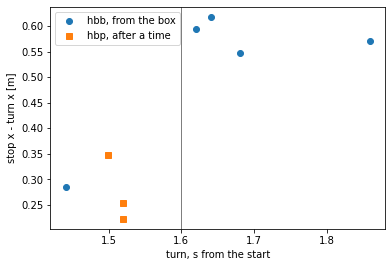

,turn [s],turn x [m],stop x - turn [m],stop y [m]
run,,,,
hbb_1,1.441,0.964,0.286,1.265
hbb_2,1.640,1.148,0.617,1.163
hbb_3,1.620,1.152,0.595,1.175
hbb_4,1.680,1.262,0.547,1.026
hbb_5,1.859,1.456,0.571,0.977


In [5]:
cars['turn x [m]'] = cars['A far corner [m]'] - cars['corner at the turn [m]']
cars['stop x - turn [m]'] = cars['stop x [m]'] - cars['turn x [m]']
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cars['turn [s]'], cars['stop x - turn [m]'], 'C0o', label='hbb, from the box')
for run, r in STRAIGHT.iterrows():
    ax.plot(r['turn [s]'], r['stop x - turn [m]'], 'C1s', label='hbp, after a time' if run == 'hbp_1' else None)
ax.axvline(1.6, color='k', lw=0.5)
ax.set(xlabel='turn, s from the start', ylabel='stop x - turn x [m]')
ax.legend()
plt.show()
cars[['turn [s]', 'turn x [m]', 'stop x - turn [m]', 'stop y [m]']].round(3)

### Result

The node finds the corner and turns where it should: -0.07 m in the first version, 0.24 m now (target
0.26). Turning before 1.6 s the car still speeds up, and from the turn to the stop it covers 0.22-0.35
m (`hbp`, `hbb_1`); turning after, 0.55-0.62 m over four runs, within 2 cm in the two turning at the
same spot (`hbb_2`, `hbb_3`). Hence the wait to 1.6 s, and `turn_at` 0.26 m for about 10 cm between
the nose and box A. With the node now, box A found 19 cm further (1.505 to 1.697 m) moved the stop 22
cm: the nose stopped 7.0 and 7.6 cm from A. Sideways it did not: 1.03 and 0.98 m left of the start,
7.1 and 33.1 cm from B.

### Sideways

The yaw rate in the turn of the four runs turning at full speed:

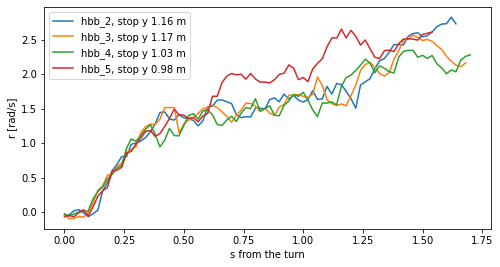

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, run in enumerate(['hbb_2', 'hbb_3', 'hbb_4', 'hbb_5']):
    d = load(run)
    s = d['state']
    turn = s[(s['t'] >= d['t_turn']) & (s['t'] <= d['t_brake'])]
    ax.plot(turn['t'] - d['t_turn'], turn['r'], f'C{i}', label=f"{run}, stop y {cars.loc[run, 'stop y [m]']:.2f} m")
ax.set(xlabel='s from the turn', ylabel='r [rad/s]')
ax.legend()
plt.show()

The four turns start the same, the yaw rate within 0.1 rad/s for half a second; then the rear steps
out, at ~0.6 s in `hbb_5`, ~1.2 s in `hbb_4`, ~1.3 s in `hbb_2` and `hbb_3`. The sooner, the tighter
the rest of the turn and the less the car goes left: 0.98 to 1.18 m. At full lock and full throttle the
turn is at the limit of the rear and the floor decides when it lets go. Sideways the stop needs the turn
itself under control.

## The turn under control

Step 11.3. At full lock and full throttle the rear lets go when the floor decides. In grip, a steering
below full lock at 1.0 m/s (below what the motor reaches, the speed loop holding it), the rear does not
let go: `handbrake_node` `turn_steer`, `turn_speed`. No boxes; the straight after a time (0.6 s at
full throttle, the turn ~1.6 s from the start), steering 0.45, brake at 150 deg. `hbg_1`-`3`: the
straight with the wheels straight; `hbl_1`-`3`: the straight on the line of the start (pure pursuit,
lookahead 0.4 m, the offset from the wheels and the gyro heading).

In [7]:
rows = []
for run in ['hbg_1', 'hbg_2', 'hbg_3', 'hbl_1', 'hbl_2', 'hbl_3']:
    d = load(run)
    s = d['state']
    x, y, yaw, rms, share = stop_pose(run)
    turn = s[(s['t'] > d['t_turn'] + 0.4) & (s['t'] < d['t_brake'])]
    rows.append({'run': run, 'heading at the turn [deg]': np.degrees(np.interp(d['t_turn'], s['t'], s['heading'])),
                 'r in the turn, max [rad/s]': turn['r'].max(), 'stop x [m]': x, 'stop y [m]': y,
                 'stop [deg]': np.degrees(yaw) % 360, 'ICP rms [cm]': 100 * rms})
grip = pd.DataFrame(rows).set_index('run')
grip.round(3)

,heading at the turn [deg],"r in the turn, max [rad/s]",stop x [m],stop y [m],stop [deg],ICP rms [cm]
run,,,,,,
hbg_1,1.775,1.914,1.472,1.084,179.493,1.357
hbg_2,1.285,2.109,1.551,1.036,179.122,1.146
hbg_3,0.679,1.994,1.510,1.022,182.595,1.283
hbl_1,-1.594,2.117,1.519,0.958,183.825,1.386
hbl_2,-2.099,2.195,1.503,0.939,185.123,1.290
hbl_3,-2.128,2.191,1.558,0.935,181.895,1.299


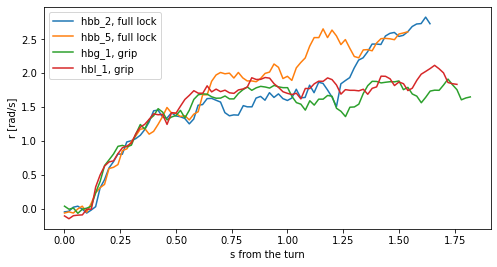

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, run in enumerate(['hbb_2', 'hbb_5', 'hbg_1', 'hbl_1']):
    d = load(run)
    s = d['state']
    turn = s[(s['t'] >= d['t_turn']) & (s['t'] <= d['t_brake'])]
    ax.plot(turn['t'] - d['t_turn'], turn['r'], f'C{i}', label=run + (', full lock' if run.startswith('hbb') else ', grip'))
ax.set(xlabel='s from the turn', ylabel='r [rad/s]')
ax.legend()
plt.show()

### Result

In grip the yaw rate stays below 2.2 rad/s; the full-lock turns reach 2.5-2.8 when the rear lets go.
Without the line the three stops spread 8 cm along the path and 6 cm across, and across they follow
the heading at the turn, 0.7-1.8 deg: the launch veers left. On the line the heading at the turn is
-1.6 to -2.1 deg (the pure pursuit overshoots as the launch ends, the straight is short and the
steering lags) but the same each time: the stops within 5.5 cm along the path, the straight still
after a time, and 2.3 cm across.

### Where the steering puts the car

The same with the line held, steering 0.35 to 0.50 (`hbl_4`, `hbl_6`: 0.40; `hbl_7`: 0.50; `hbl_8`,
`hbl_9`: 0.35; `hbl_5` lost its scans, the lidar cable touched).

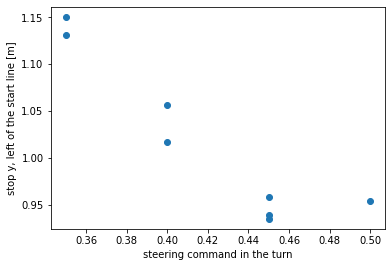

stop x [m]               stop y [m]              
               mean    min    max       mean    min    max
steering                                                  
0.35          1.544  1.519  1.569      1.141  1.131  1.150
0.40          1.500  1.500  1.500      1.037  1.018  1.057
0.45          1.527  1.503  1.558      0.944  0.935  0.958
0.50          1.468  1.468  1.468      0.954  0.954  0.954

In [9]:
STEER = {'hbl_1': 0.45, 'hbl_2': 0.45, 'hbl_3': 0.45, 'hbl_4': 0.40, 'hbl_6': 0.40, 'hbl_7': 0.50, 'hbl_8': 0.35, 'hbl_9': 0.35}
rows = []
for run, steer in STEER.items():
    x, y, yaw, rms, share = stop_pose(run)
    rows.append({'run': run, 'steering': steer, 'stop x [m]': x, 'stop y [m]': y, 'stop [deg]': np.degrees(yaw) % 360})
calib = pd.DataFrame(rows).set_index('run')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(calib['steering'], calib['stop y [m]'], 'C0o')
ax.set(xlabel='steering command in the turn', ylabel='stop y, left of the start line [m]')
plt.show()
calib.groupby('steering')[['stop x [m]', 'stop y [m]']].agg(['mean', 'min', 'max']).round(3)

### Result

From 0.35 to 0.45 the stop moves 20 cm across, 1.14 to 0.94 m, about 2 cm per 0.01 of steering,
within 2-4 cm run to run; at 0.50 it stops as at 0.45, the front at its limit at 1.0 m/s. Along the
path it moves little, 1.47-1.57 m. These are the table of the node (`stop_y`), less ~2.7 cm for the
runs turning from the box (below).

## Box B

In the straight, once the car is past box A, the side of box B is the nearest line of points further
out than the side of A and further on than its far corner (the ends of A are in between); its median
from the line of the start, scan by scan. At the turn the node takes the median of them and the
steering from the table above, to stop `side_gap` (0.10 m) from B: the rear axle at B - 0.10 - 0.10 m.
Gazebo (`sim_ab1`, `sim_ab2`), box B with its side 1.18 and 1.30 m from the line of the start:

In [10]:
rows = []
for run, b_true in [('sim_ab1', 1.18), ('sim_ab2', 1.30)]:
    d = load(run)
    s = d['state']
    t, x, y, yaw = sim_stop(run)
    drive = pd.read_parquet(f'{B}/{run}_parquet/drive.parquet')
    steer = drive.loc[(drive['t'] > d['t_turn'] + 0.2) & (drive['t'] < d['t_brake']), 'cmd_steer'].median()
    rows.append({'run': run, 'B side [m]': b_true, 'B, node [m]': s.loc[s['phase'] == 3, 'box_b'].iloc[0],
                 'steering': steer, 'stop y [m]': y.iloc[-1], 'stop, true [deg]': np.degrees(yaw.iloc[-1]) % 360})
pd.DataFrame(rows).set_index('run').round(3)

,B side [m],"B, node [m]",steering,stop y [m],"stop, true [deg]"
run,,,,,
sim_ab1,1.18,1.171,0.422,1.152,177.083
sim_ab2,1.30,1.293,0.361,1.256,176.768


The node finds B within 1 cm (1.171 and 1.293 m against 1.18 and 1.30) and steers 0.422 and 0.361;
the simulated car stops 10.4 cm further out for B 12 cm further out. It stops at 177 deg: the slide is
aimed 2.6 deg short for the car (below), and the simulated car does not turn the last degrees.

## The whole run on the car

`box:=true`, the grip turn, the boxes placed with the lidar from the start. `hbf_1`: box A with its far
corner 1.33 m ahead of the start, B at 1.19 m; `hbf_2`: B 10 cm further out; `hbf_3`: both boxes 10 cm
further on and `turn_at` 0.17 m (from `hbf_1`, `hbf_2`: 0.47-0.51 m from the turn to the stop); `hbf_4`,
`hbf_5`: the same again, the slide aimed 2.6 deg short (below).

In [11]:
rows = []
for run in ['hbf_1', 'hbf_2', 'hbf_3', 'hbf_4', 'hbf_5']:
    d = load(run)
    s = d['state']
    x, y, yaw, rms, share = stop_pose(run)
    nose, side = gaps(run)
    far = s.loc[s['phase'] == 2, 'box_far'].dropna().iloc[0]
    corner = s.loc[s['t'] <= d['t_turn'], 'box_far'].iloc[-1]
    steer = pd.read_parquet(f'{B}/{run}_parquet/drive.parquet')
    steer = steer.loc[(steer['t'] > d['t_turn'] + 0.2) & (steer['t'] < d['t_brake']), 'cmd_steer'].median()
    rows.append({'run': run, 'A far corner [m]': far, 'corner at the turn [m]': corner, 'steering': steer,
                 'stop x [m]': x, 'stop y [m]': y, 'stop, gyro [deg]': np.degrees(s['heading'].iloc[-1]),
                 'nose to A [cm]': 100 * nose, 'side to B [cm]': 100 * side, 'ICP rms [cm]': 100 * rms})
whole = pd.DataFrame(rows).set_index('run')
# against the timed runs above at the same steering
whole['stop y - timed [cm]'] = 100 * (whole['stop y [m]'] - np.interp(whole['steering'], [0.35, 0.40, 0.45], [1.14, 1.04, 0.94]))
print(f"stop y - timed runs: {whole['stop y - timed [cm]'].mean():+.1f} cm on average")
whole.round(3)

stop y - timed runs: -2.7 cm on average


,A far corner [m],corner at the turn [m],steering,stop x [m],stop y [m],"stop, gyro [deg]",nose to A [cm],side to B [cm],ICP rms [cm],stop y - timed [cm]
run,,,,,,,,,,
hbf_1,1.332,0.043,0.425,1.763,0.993,181.245,16.378,9.394,2.225,0.243
hbf_2,1.327,0.040,0.369,1.796,1.089,185.191,20.381,11.330,2.196,-1.300
hbf_3,1.432,0.145,0.384,1.784,1.050,181.020,9.154,14.731,2.082,-2.268
hbf_4,1.426,0.150,0.377,1.793,1.037,180.868,10.170,15.154,2.225,-4.892
hbf_5,1.435,0.165,0.373,1.752,1.043,175.871,6.364,14.123,2.284,-5.208


### Result

The car finds A along the path and B across and parks between them. With B 10 cm further out
(`hbf_1`, `hbf_2`) the node steered 0.369 instead of 0.425 and stopped 9.6 cm further out, 9.4 and 11.3
cm from B. With `turn_at` 0.17 m the nose stops 6-10 cm from A. The three runs with the same boxes
(`hbf_3`-`5`) stopped within 4.1 cm along the path and 1.3 cm across, 14-15 cm from B, 5 cm more than
`side_gap`: turning from the box the car stopped 2.7 cm less far out than the timed runs at the same
steering, now in the table of the node; the rest is the spread from one layout to the other.

### The heading at the stop

All the grip turns stopped past the target:

In [12]:
rows = []
for run in ['hbl_1', 'hbl_2', 'hbl_3', 'hbl_4', 'hbl_6', 'hbl_7', 'hbl_8', 'hbl_9', 'hbf_1', 'hbf_2', 'hbf_3', 'hbf_4', 'hbf_5']:
    s = load(run)['state']
    rows.append({'run': run, 'aimed short': run in ('hbf_4', 'hbf_5'), 'stop, gyro [deg]': np.degrees(s['heading'].iloc[-1])})
heads = pd.DataFrame(rows).set_index('run')
heads.groupby('aimed short')['stop, gyro [deg]'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)

,mean,std,min,max,count
aimed short,,,,,
False,182.58,1.47,180.89,185.19,11
True,178.37,3.53,175.87,180.87,2


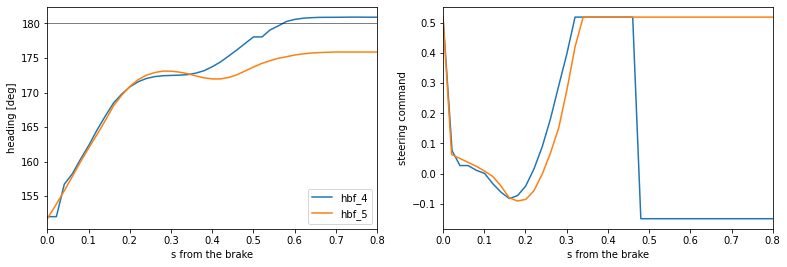

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, run in enumerate(['hbf_4', 'hbf_5']):
    d = load(run)
    s = d['state']
    sl = s[s['phase'] == 4]
    ax[0].plot(sl['t'] - d['t_brake'], np.degrees(sl['heading']), f'C{i}', label=run)
    ax[1].plot(sl['t'] - d['t_brake'], sl['steer'], f'C{i}', label=run)
ax[0].axhline(180, color='k', lw=0.5)
ax[0].set(xlabel='s from the brake', ylabel='heading [deg]', xlim=(0, 0.8))
ax[1].set(xlabel='s from the brake', ylabel='steering command', xlim=(0, 0.8))
ax[0].legend()
plt.show()

The 11 grip turns aimed at 180 deg stopped at 182.6 +- 1.5 deg: the model misses the last degrees,
when the car has nearly stopped and turns on the steering it has (the yaw rate rises again at
0.35-0.6 s). The node aims 2.6 deg short. Of the two runs since, `hbf_4` stopped at 180.9 deg and `hbf_5`
at 175.9: the same steering for 0.3 s, then in `hbf_5` the steering came back from the countersteer a
step later, the nearly stopped car turned back 1 deg and full lock no longer turned it. The heading
is within 3 deg; the slide as the wheels lock is where the model is weakest.